### Currently the code executes a 6 cell split, in order to change it to any other cell split, go to the `meshroutines` section, under which look for the function named `mesh_allsplit` update this section of the code                 
        if (v.index() in int_vtx) and (nrvstar[v.index()] == 6):
        # Change 6 to 3,4 or 5 for split according to your choice

### Furthermore, come to the first main file `main_IPM_plots_over_iter=16` here, look for these lines of codes,

        errortable_iter.to_csv(f"errors_{opt_meshmod}_6.csv", index=False)

### You can find it in the first ####Solve#### section of codes, so change 6 according to your cell split

### Again in the 2nd last line of the same main file, update this line of code as well,

    errortable.to_csv(f"errors_rho_{float(rho)}_6.csv", index=False)


In [1]:
try:
    import dolfin
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/fenics-install-release-real.sh" -O "/tmp/fenics-install.sh" && bash "/tmp/fenics-install.sh"
    import dolfin

In [2]:
import mshr

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
from dolfin import *

## The code below is from the auxillary_methods.py file

In [5]:
def pressure_zero_mean(p, mesh, pdeg, fct_type):
    '''
    Input:
    p: given function either as Expression() or Coefficient()
    mesh: mesh of the domain as Fenics mesh,
    pdeg: polynomial degree of the velocity finite element space,
    fct_type: type of function that should be corrected given as string,
    Output:
    p_cor: corrected function with now zero mean given as Coefficient().
    '''
    if fct_type == 'exact': # higher polynomial degree to interpolate exact sol
        DG = FunctionSpace(mesh, "DG", pdeg+2)
        vol = assemble(Constant(1)*dx(mesh))
        p_proj= project(p,DG)
        p_cor = Function(DG)
        p_cor = p_proj - assemble(p_proj*dx(mesh))/vol
    elif fct_type == 'approx':
        DG = FunctionSpace(mesh, "DG", pdeg-1)
        vol = assemble(Constant(1)*dx(mesh))
        p_proj= project(p,DG)
        p_cor = Function(DG)
        p_cor = p_proj - assemble(p_proj*dx(mesh))/vol

    return(p_cor)

def pressure_error(p_ex, p_approx, mesh):
    '''
    Input:
    p_ex: exact pressure solution given as Expression(),
    p_approx: approximated pressure given as Coefficient(),
    mesh: mesh of the domain as Fenics mesh,
    Output:
    p_error: absolute L2 pressure error,
    p_relerror: relative L2 pressure error.
    '''
    p_error=sqrt(assemble((p_ex-p_approx)**2*dx(mesh)))

    pnorm=sqrt(assemble((p_ex)**2*dx(mesh)))

    p_relerror = float('NaN')
    if pnorm > 1e-9:
        p_relerror = p_error/pnorm

    return(p_error, p_relerror)

## The code below is from boundary_methods.py file

In [6]:
from mshr import *

In [7]:
# Function to compute the length of the facet
def compute_facet_length(facet):
    '''
    Input:
    facet: a facet of the mesh,
    Output:
    length: facet length as Constant().
    '''
    v = [vertex.point() for vertex in vertices(facet)]
    length = v[0].distance(v[1])
    return length

def boundary_modification(V, mesh, gh):
    '''
    Input:
    V: finite element velocity space,
    mesh: mesh of the domain as Fenics mesh,
    gh: discrete boundary data given as Coefficient(),
    Output:
    gh_corrected: corrected boundary data compatible with divergence constraint as Coefficient().
    '''
    # Define scalar function space
    CG2 = FunctionSpace(mesh, "Lagrange", 2)
    # Get DOF coordinates in the scalar function space CG2
    dof_coords_CG2 = CG2.tabulate_dof_coordinates().reshape((-1, mesh.geometry().dim()))

    # Define function spaces
    CG2 = FunctionSpace(mesh, "Lagrange", 2) # scalar function space
    DG0_vec = VectorFunctionSpace(mesh,"DG", 0)
    CG2_vec = VectorFunctionSpace(mesh, "Lagrange", 2)

    # Get DOF coordinates in the scalar function space CG2
    dof_coords_CG2 = CG2.tabulate_dof_coordinates().reshape((-1, mesh.geometry().dim()))

    ds = Measure("ds", domain=mesh, subdomain_data=None)

    # Define the normal vector on the boundary facets
    n = FacetNormal(mesh)

    # error of normal trace int made in approximation of g
    int_gh_n = assemble(dot(gh, n) * ds)

    # Initialize a scalar correction function
    cs = Function(CG2)
    for facet in facets(mesh):
        if facet.exterior():
            # Compute the length of the facet
            facet_length = compute_facet_length(facet)

            # Compute the correction coefficient cf
            cf = (6.0 / facet_length) * int_gh_n

            # Find the DOF index that matches the midpoint coordinates
            midpoint = facet.midpoint()
            dof_index = -1
            for i, coord in enumerate(dof_coords_CG2):
                if np.allclose(coord, [midpoint.x(), midpoint.y()]):
                    dof_index = i # `dof_index` holds the index of the DOF corresponding to the midpoint of the current facet
                    break

            cs.vector()[dof_index] = 0.25 * cf
        break

    # Solve for the normal as vector function in DG0_vec
    u = TrialFunction(DG0_vec)
    v = TestFunction(DG0_vec)
    a = inner(u,v)*ds(None)
    l = inner(n, v)*ds(None)
    A = assemble(a, keep_diagonal=True)
    L = assemble(l)

    A.ident_zeros()
    n_vec = Function(DG0_vec)
    solve(A, n_vec.vector(), L)

    # Interpolate the normal into the CG2 vector space
    n_vec = interpolate(n_vec, CG2_vec)

    # obtain scalar correction as a vector function
    cs_vec = Function(CG2_vec)
    cs_vec.vector()[:] = np.repeat(cs.vector(),2) # repeat([a b],2) gives [a a b b]

    # cs times normal components as CG2 vector function
    csn = Function(CG2_vec)
    csn.vector()[:] = np.multiply(cs_vec.vector()[:], n_vec.vector()[:])

    # interpolate csn into possibly higher polynomial space
    csn = interpolate(csn,V)

    # substract correction term from original interpolation gh
    gh_corrected = Function(V)
    gh_corrected.vector()[:] = gh.vector()[:] - csn.vector()[:]

    return gh_corrected

## The code below is from meshroutines.py file

In [8]:
def mesh_cornermod(mesh,plotopt):
    '''
    Input:
    mesh: mesh of the domain,
    plotopt: integer 0,1 indicates whether the mesh is plotted or not,
    Output:
    new_mesh: corner-modified mesh as Fenics mesh
    '''

    ## mesh quantities
    mesh.init()
    vnr = mesh.num_vertices()  # nr of vertices in mesh
    tnr = mesh.num_cells()     # nr of triangles in mesh

    ## FEM space
    V = FunctionSpace(mesh, "CG", 1)
    vd_map  = vertex_to_dof_map(V)                  # vertex to dof map: ith entry contains vertex index of ith dof
    dv_map  = dof_to_vertex_map(V)                  # vertex to dof map: ith entry contains the dof of ith vtx
    coords = mesh.coordinates()                     # all coordinates of vtx in mesh, sorted by index of dof
    coords_vtx = mesh.coordinates()[dv_map]         # all coordinates of vtx in mesh, sorted by index of vtx

    bd_dof, bdidx_vtx, int_vtx = get_bdcoord(V,vnr,dv_map)

    ## initialisation lists
    nrvstar = []        # array where ith entry contains number of triangles adjacent to vertex i
    vlistelem = []      # ith entry contains list of indices of triangles that contain vertex i

    ## assembly of lists
    for v in vertices(mesh):        # loop over vertex indices
        if plotopt == 1:
            co = coords_vtx[v.index(),:]
            plt.text(co[0]+0.01, co[1]-0.02, str(v.index()))            # vertex index
            plt.text(co[0]+0.02, co[1]+0.02, str(dv_map[v.index()]))    # dof index
        varr = []
        for c in cells(v):
            varr.append(c.index())
        vlistelem.append(varr)
        nrvstar.append(np.size(varr))

    ## determine triangles in ngbh of possibly singular vertices
    triangle1 = []       # list of indices of triangles with only boundary vertices
    triangle2 = []       # list of indices of triangles that are the unique neighbor
    vcorner = []         # list of corner vertices
    v1 = []              # vertex 1 on edge between T1 and T2
    v2 = []              # vertex 1 on edge between T1 and T2
    vinner = []          # third (interior) vertex of T2

    np.asarray(triangle1)
    np.asarray(triangle2)
    np.asarray(vcorner)
    np.asarray(v1)
    np.asarray(v2)
    np.asarray(vinner)
    #print(vlistelem)

    ## assembly of list of triangles with only boundary vertices
    for v in vertices(mesh):
      if plotopt == 1:
        if v.index() in bdidx_vtx:
          co = coords_vtx[v.index(),:]
          plt.plot(co[0], co[1], 'bo') # 'bo' stands for blue circle
      if nrvstar[v.index()] == 1:
        triangle = vlistelem[v.index()]
        triangle1.append(triangle[0])
        vcorner.append(v.index())
    #print(triangle1,vcorner)

    for j in range(len(triangle1)):  # iterate over all triangles with only boundary vertices
      cornercell = Cell(mesh, triangle1[j])
      covnercellvtx = [v.index() for v in vertices(cornercell)]
      nocornervlist = [x for x in covnercellvtx if x != vcorner[j]]
      #print(covnercellvtx,nocornervlist)

      for cell in cells(mesh):
        cellvtx = [v.index() for v in vertices(cell)]
        if all(elem in cellvtx for elem in nocornervlist) and cell.index() != triangle1[j]:
          triangle2.append(cell.index())
          inner = [x for x in cellvtx if x not in  nocornervlist]
          vinner.append(inner[0])
          v1.append(nocornervlist[0])
          v2.append(nocornervlist[1])
    #print(triangle2,vinner,v1,v2)

    ## generate new cells and new mesh
    new_cells = mesh.cells()
    for j in range(len(triangle1)):
        T1new = np.array([vcorner[j], v1[j],vinner[j]])
        T2new = np.array([vcorner[j], v2[j],vinner[j]])
        new_cells[triangle1[j]] = T1new
        new_cells[triangle2[j]] = T2new
    new_mesh = get_mesh(coords,new_cells)

    return(new_mesh)

########################################
# modification of the mesh to get rid of nearly singular vertices

def mesh_allsplit(oldmesh, plotopt):
    '''
    Input:
    oldmesh: Fenics mesh
    plotopt: integer 0,1 indicates whether the mesh is plotted or not,
    Output:
    new_mesh: locally modified mesh as Fenics mesh
    '''
    mesh = mesh_cornermod(oldmesh, plotopt)     # modification of triangles with all vertices on bd (corner, see below)

    ## mesh quantities
    mesh.init()
    vnr = mesh.num_vertices()  # nr of vertices in mesh

    ## FEM space
    V = FunctionSpace(mesh, "CG", 1)
    dv_map  = dof_to_vertex_map(V)                  # vertex to dof map: ith entry contains the dof of ith vtx
    coords_vtx = mesh.coordinates()[dv_map]         # all coordinates of vtx in mesh, sorted by index of vtx

    bd_dof, bdidx_vtx, int_vtx = get_bdcoord(V,vnr,dv_map)

    ## initialisation lists
    nrvstar = []        # array where ith entry contains number of triangles adjacent to vertex i
    vlistelem = []      # ith entry contains list of indices of triangles that contain vertex i

    ## assembly of lists
    for v in vertices(mesh):        # loop over vertex indices
        if plotopt == 1:
            co = coords_vtx[v.index(),:]
            plt.text(co[0]+0.01, co[1]-0.02, str(v.index()))            # vertex index
            plt.text(co[0]+0.02, co[1]+0.02, str(dv_map[v.index()]))    # dof index
        varr = []
        for c in cells(v):
            varr.append(c.index())
        vlistelem.append(varr)
        nrvstar.append(np.size(varr))

    ## determine triangles in neighborhood of possibly singular vertices
    singelem = []       # list of indices triangles adjacent to (possibly) singular or nearly singular vertices
    np.asarray(singelem)
    ## assembly of lists
    for v in vertices(mesh):
        if plotopt == 1:
            if v.index() in bdidx_vtx:
                co = coords_vtx[v.index(),:]
                plt.plot(co[0], co[1], 'bo') # 'bo' stands for blue circle
        if (v.index() in int_vtx) and (nrvstar[v.index()] == 4):
            singelem.append(vlistelem[v.index()])
        if (v.index() in bd_dof) and (nrvstar[v.index()] <= 2):  # convrc domain: two triangles meeting in one dof are possibly (nearly) singular
            singelem.append(vlistelem[v.index()])
    if len(singelem)>0:
        # singelem_list = np.unique(np.concatenate(singelem).ravel())
        # selected_triangles = [group[0] for group in singelem] # for 1 cell split
        selected_triangles = []

        # --- TOGGLE SWITCH ---
        # Set to 0 to split the first pair of triangles.
        # Set to 1 to split the symmetrically opposite pair.
        pair_toggle = 1

        for group in singelem:
            # Check if this is an interior singular vertex (4 triangles meeting)
            if len(group) == 4:
                if pair_toggle == 0:
                    # Grab the first two triangles
                    selected_triangles.extend([group[0], group[2]])
                else:
                    # Grab the remaining two triangles
                    selected_triangles.extend([group[1], group[3]])
            else:
                # For boundary singular vertices (which have 2 or fewer triangles),
                # just split whatever is there to be safe.
                selected_triangles.extend(group)

        # Ensure no duplicates in case two singular vertices share the same triangle
        singelem_list = np.unique(selected_triangles)
        new_mesh = ref_barymarked(V,mesh,singelem_list,dv_map)
    else:
        singelem_list = []
        print("There are no possibly singular vertices")
        new_mesh = mesh

    print(f"Old mesh had {mesh.num_cells()} triangles.")
    print(f"New mesh has {new_mesh.num_cells()} triangles.")
    return(new_mesh)




def mesh_allsplit_incenter(oldmesh, plotopt):
    '''
    Input:
    oldmesh: Fenics mesh
    plotopt: integer 0,1 indicates whether the mesh is plotted or not,
    Output:
    new_mesh: locally modified mesh as Fenics mesh
    '''
    mesh = mesh_cornermod(oldmesh, plotopt)     # modification of triangles with all vertices on bd (corner, see below)

    ## mesh quantities
    mesh.init()
    vnr = mesh.num_vertices()  # nr of vertices in mesh

    ## FEM space
    V = FunctionSpace(mesh, "CG", 1)
    dv_map  = dof_to_vertex_map(V)                  # vertex to dof map: ith entry contains the dof of ith vtx
    coords_vtx = mesh.coordinates()[dv_map]         # all coordinates of vtx in mesh, sorted by index of vtx

    bd_dof, bdidx_vtx, int_vtx = get_bdcoord(V,vnr,dv_map)

    ## initialisation lists
    nrvstar = []        # array where ith entry contains number of triangles adjacent to vertex i
    vlistelem = []      # ith entry contains list of indices of triangles that contain vertex i

    ## assembly of lists
    for v in vertices(mesh):        # loop over vertex indices
        if plotopt == 1:
            co = coords_vtx[v.index(),:]
            plt.text(co[0]+0.01, co[1]-0.02, str(v.index()))            # vertex index
            plt.text(co[0]+0.02, co[1]+0.02, str(dv_map[v.index()]))    # dof index
        varr = []
        for c in cells(v):
            varr.append(c.index())
        vlistelem.append(varr)
        nrvstar.append(np.size(varr))

    ## determine triangles in neighborhood of possibly singular vertices
    singelem = []       # list of indices triangles adjacent to (possibly) singular or nearly singular vertices
    np.asarray(singelem)
    ## assembly of lists
    for v in vertices(mesh):
        if plotopt == 1:
            if v.index() in bdidx_vtx:
                co = coords_vtx[v.index(),:]
                plt.plot(co[0], co[1], 'bo') # 'bo' stands for blue circle
        if (v.index() in int_vtx) and (nrvstar[v.index()] == 4):
            singelem.append(vlistelem[v.index()])
        if (v.index() in bd_dof) and (nrvstar[v.index()] <= 2):  # convrc domain: two triangles meeting in one dof are possibly (nearly) singular
            singelem.append(vlistelem[v.index()])
    if len(singelem)>0:
        singelem_list = np.unique(np.concatenate(singelem).ravel())
        new_mesh = ref_powell_sabin(V,mesh,singelem_list,dv_map)
    else:
        singelem_list = []
        print("There are no possibly singular vertices")
        new_mesh = mesh

    return(new_mesh)


########################################
# extract list of dofs and indices for boundary vertices, and interior vertices

def get_bdcoord(V,vnr,dv_map):
    '''
    Input:
    V: finite element velocity space,
    vnr: number of vertices as integer,
    dv_map: dof to vertex map in Fenics,
    Output:
    bd_dof: list of indices of boundary vertices,
    bdidx_vtx: list of indices of boundary vertices as numpy array,
    int_vtx: list of indices of interior vertices.
    '''
    ## bc
    bc = DirichletBC(V, Constant(0.0),'on_boundary')
    bdidx_vtx = np.array(list(bc.get_boundary_values().keys())) # indices of vtx on bd

    # single out boundary / interior vertices
    bd_dof = dv_map[bdidx_vtx]                       # bd dofs
    all_vtx = np.arange(vnr)                        # indices of all vtx
    int_vtx = np.setdiff1d(all_vtx,bd_dof)          # indices of interior vtx
    return(bd_dof, bdidx_vtx, int_vtx)

##########################################
#generate new mesh from list of coordinates and list of cells
def get_mesh(coord_list,cell_list):
    '''
    Input:
    coord_list: list of coordinates as mesh.coordinates()
    cell_list: list of cells as mesh.cells()
    Output:
    mesh: Fenics mesh generated from list of coordinates and list of cells
    '''
    ## new mesh
    editor = MeshEditor()
    mesh = Mesh()

    editor.open(mesh,'triangle', 2, 2)
    editor.init_vertices(np.size(coord_list,0))
    editor.init_cells(np.size(cell_list,0))

    # assign new vertices
    for vid in range(np.size(coord_list,0)):
        ncord = coord_list[vid,:]
        editor.add_vertex(vid, ncord)

    # assign new cells
    for j in range(np.size(cell_list,0)):
        editor.add_cell(j, cell_list[j,:])

    editor.close()
    return(mesh)

#####################################
# refine cells with indices in tindlist by Alfeld split


# def ref_barymarked(V,mesh,tindlist,dv_map):
#     '''
#     Input:
#     V: finite element velocity space,
#     mesh: mesh of domain as Fenics mesh,
#     tindlist: list of indices of cells,
#     dv_map: dof to vertex map in Fenics,
#     Output:
#     new_mesh: modified mesh as Fenics mesh.
#     '''
#     ## generate new vertices (barycenters)
#     vbary_coord = []        # coordinates of barycenters
#     newel_vtx = np.array([0, 0, 0])          # index list: new elements (in rows); auxiliary row (deleted later)
#     coords_vtx = mesh.coordinates()[dv_map]         # all coordinates of vtx in mesh, sorted by index of vtx
#     vind_new = mesh.num_vertices()

#     # Select only the first triangle from the list
#     tind_single = tindlist[0]

#     tdofs = V.dofmap().cell_dofs(tind_single)
#     tvtx = np.take(dv_map,tdofs)
#     tdofs_coord = np.take_along_axis(coords_vtx, tdofs[...,None], axis=0)     # coordinates
#     ncoord = 1./3.*np.sum(tdofs_coord,axis = 0)
#     vbary_coord.append(ncoord)
#     newtsplit1 = np.array([tvtx[0], tvtx[1], vind_new])       # first new triangle (by vtx incides)
#     newtsplit2 = np.array([tvtx[1], tvtx[2], vind_new])       # second new triangle (by vtx incides)
#     newtsplit3 = np.array([tvtx[0], tvtx[2], vind_new])       # third new triangle (by vtx incides)
#     newtsplit = np.vstack((newtsplit1,newtsplit2,newtsplit3))
#     newel_vtx = np.vstack((newel_vtx,newtsplit))

#     newel_vtx = np.delete(newel_vtx, 0, axis = 0)   # delete first row again
#     newel_vtx_int = newel_vtx.astype(int)

#     old_coord = mesh.coordinates()
#     new_coord = np.concatenate((old_coord,vbary_coord),axis = 0)

#     ## generate new cells
#     old_cells = mesh.cells()

#     # Delete ONLY the single triangle we just split
#     new_cells = np.delete(old_cells, tind_single, axis = 0)

#     new_cells = np.vstack((new_cells,newel_vtx_int))

#     new_mesh = get_mesh(new_coord,new_cells)

#     return(new_mesh)

def ref_barymarked(V,mesh,tindlist,dv_map):
    '''
    Input:
    V: finite element velocity space,
    mesh: mesh of domain as Fenics mesh,
    tindlist: list of indices of cells,
    dv_map: dof to vertex map in Fenics,
    Output:
    new_mesh: modified mesh as Fenics mesh.
    '''
    ## generate new vertices (barycenters)
    vbary_coord = []        # coordinates of barycenters
    newel_vtx = np.array([0, 0, 0])          # index list: new elements (in rows); auxiliary row (deleted later)
    coords_vtx = mesh.coordinates()[dv_map]         # all coordinates of vtx in mesh, sorted by index of vtx
    vind_new = mesh.num_vertices()

    for tind in tindlist:
        tdofs = V.dofmap().cell_dofs(tind)
        tvtx = np.take(dv_map,tdofs)
        tdofs_coord = np.take_along_axis(coords_vtx, tdofs[...,None], axis=0)     # coordinates
        ncoord = 1./3.*np.sum(tdofs_coord,axis = 0)
        vbary_coord.append(ncoord)
        newtsplit1 = np.array([tvtx[0], tvtx[1], vind_new])       # first new triangle (by vtx incides)
        newtsplit2 = np.array([tvtx[1], tvtx[2], vind_new])       # second new triangle (by vtx incides)
        newtsplit3 = np.array([tvtx[0], tvtx[2], vind_new])       # third new triangle (by vtx incides)
        newtsplit = np.vstack((newtsplit1,newtsplit2,newtsplit3))
        newel_vtx = np.vstack((newel_vtx,newtsplit))
        vind_new = vind_new + 1

    newel_vtx = np.delete(newel_vtx, 0, axis = 0)   # delete first row again
    newel_vtx_int = newel_vtx.astype(int)

    old_coord = mesh.coordinates()
    new_coord = np.concatenate((old_coord,vbary_coord),axis = 0)

    ## generate new cells
    old_cells = mesh.cells()
    new_cells = np.delete(old_cells, tindlist, axis = 0)
    new_cells = np.vstack((new_cells,newel_vtx_int))

    new_mesh = get_mesh(new_coord,new_cells)

    return(new_mesh)

def ref_powell_sabin(V, mesh, tindlist, dv_map):
    '''
    Input:
    V: finite element velocity space,
    mesh: mesh of domain as Fenics mesh,
    tindlist: list of indices of cells,
    dv_map: dof to vertex map in Fenics,
    Output:
    new_mesh: modified mesh with Incenter (Powell-Sabin strategy) split.
    '''
    ## generate new vertices (Incenters)
    vincenter_coord = []
    newel_vtx = np.array([0, 0, 0])
    coords_vtx = mesh.coordinates()[dv_map]
    vind_new = mesh.num_vertices()

    for tind in tindlist:
        tdofs = V.dofmap().cell_dofs(tind)
        tvtx = np.take(dv_map, tdofs)

        # ---------------------------------------------------------------------------------------
        # Get coordinates of the 3 vertices: A, B, C
        tdofs_coord = np.take_along_axis(coords_vtx, tdofs[...,None], axis=0)
        A = tdofs_coord[0]
        B = tdofs_coord[1]
        C = tdofs_coord[2]

        # Calculate Edge Lengths
        # a is length opposite to A (distance between B and C)
        a = np.linalg.norm(B - C)
        b = np.linalg.norm(A - C)
        c = np.linalg.norm(A - B)

        # Calculate Incenter
        perimeter = a + b + c
        ncoord = (a * A + b * B + c * C) / perimeter

        vincenter_coord.append(ncoord)
        # -----------------------------------------------------------------------------------------

        # The topology (connectivity) remains 1-to-3, which is safe for local refinement
        newtsplit1 = np.array([tvtx[0], tvtx[1], vind_new])
        newtsplit2 = np.array([tvtx[1], tvtx[2], vind_new])
        newtsplit3 = np.array([tvtx[2], tvtx[0], vind_new]) # Note: distinct order to match 0-1, 1-2, 2-0 pattern

        newtsplit = np.vstack((newtsplit1, newtsplit2, newtsplit3))
        newel_vtx = np.vstack((newel_vtx, newtsplit))
        vind_new = vind_new + 1

    newel_vtx = np.delete(newel_vtx, 0, axis = 0)
    newel_vtx_int = newel_vtx.astype(int)

    old_coord = mesh.coordinates()
    new_coord = np.concatenate((old_coord, vincenter_coord), axis = 0)

    ## generate new cells
    old_cells = mesh.cells()
    new_cells = np.delete(old_cells, tindlist, axis = 0)
    new_cells = np.vstack((new_cells, newel_vtx_int))

    new_mesh = get_mesh(new_coord, new_cells)

    return(new_mesh)

## The code below is from stokes_methods_gf.py file

In [9]:
import pandas as pd
import time

In [10]:
pd.set_option('display.precision', 2)

In [11]:

########### IPM ###########

def IPM(V, mesh, f, gh, pdeg, nu, rho, max_iters, tol_div, ue, pe):
    '''
    Input:
        V: finite element velocity space,
        mesh: mesh of the domain as Fenics mesh,
        f: data of the PDE given as Expression(),
        gh: discrete boundary data given as Coefficient(),
        pdeg: polynomial degree of the velocity space given as integer,
        nu: viscosity coefficient given as Constant(),
        rho: penalty parameter given as Constant(),
        max_iters: maximum number of IPM iterations given as integer,
        tol_div: tolerance for the IPM stopping criterion given as Constant(),
        ue: exact velocity solution given as Expression(),
        pe: exact pressure solution given as Expression(),
    Output:
        uh: discrete velocity approximation as Function(V),
        div_uh_norm: L2 norm of the divergence of uh ,
        ph: discrete pressure approximation,
        errortable_iter: L2, H1 velocity errors, L2 divergence and pressure errors in each iteration given as Panda DataFrame().
    '''
    # input:
    ######### Initialise DataFrame for error data of methods solution ##########
    errortable_iter = pd.DataFrame()

    u = TrialFunction(V)
    vs = TestFunction(V)
    phi = Function(V)

    uh = Function(V)

    bSt = nu*inner(grad(u), grad(vs))*dx + rho*div(u)*div(vs)*dx
    L = inner(f,vs)*dx + div(phi)*div(vs)*dx

    bc = DirichletBC(V, gh, "on_boundary")

    pde = LinearVariationalProblem(bSt, L, uh, bc)
    solver = LinearVariationalSolver(pde)

    # Scott-Vogelius iterated penalty method
    iters = 0;  div_uh_norm = 1
    while iters < max_iters and div_uh_norm > tol_div:
        # solve for new uh
        solver.solve()

        # update phi
        phi.vector().axpy(-rho, uh.vector())

        # approximate pressure
        ph = div(phi)
        ph = pressure_zero_mean(ph, mesh, pdeg, 'approx')

        iters += 1

        # Calculating the errors
        div_uh_norm = sqrt(assemble(div(uh)*div(uh)*dx(mesh)))
        L2_uh = errornorm(ue, uh, norm_type='L2', degree_rise=3)
        H1_uh = errornorm(ue, uh, norm_type='H1', degree_rise=3)
        L2_ph_abs, L2_ph_rel = pressure_error(pe, ph, mesh)
        newrow_divuh = pd.DataFrame({'iter': [iters], 'L2 error uh': [L2_uh], 'H1 error uh': [H1_uh], 'L2 div uh': [div_uh_norm],
                                    'abs L2 error ph': [L2_ph_abs]})
        errortable_iter = pd.concat([errortable_iter, newrow_divuh], ignore_index = True)

    return( uh, div_uh_norm, ph, errortable_iter )


########### Mixed methods ###########

def mixed_method(methodtype, mesh, f, gh, pdeg, nu, opt_method_solver):
    '''
    Input:
        methodtype: type of method given as string,
        mesh: mesh of the domain as Fenics mesh,
        f: data of the PDE given as Expression(),
        gh: discrete boundary data given as Coefficient(),
        pdeg: polynomial degree of the velocity space given as integer,
        nu: viscosity coefficient given as Constant(),
        opt_method_solver: list of strings detailing the method type and linear solver used,
    Output:
        uh: discrete velocity approximation as Function(V),
        div_uh_norm: L2 norm of the divergence of uh,
        ph: discrete pressure approximation.
    '''
    lin_solver = opt_method_solver[2]

    if methodtype == "SV":
        pressure_space = 'DG'
    elif methodtype == "TH":
        pressure_space = 'P'
    else:
        print("Error: pressure space in mixed method")

    VvecElem = VectorElement('P',mesh.ufl_cell(),pdeg)
    QElem = FiniteElement(pressure_space,mesh.ufl_cell(),pdeg-1)
    V = FunctionSpace(mesh,VvecElem)
    Q = FunctionSpace(mesh,QElem)
    X = FunctionSpace(mesh,MixedElement([VvecElem,QElem]))

    u,p = TrialFunctions(X)
    v,q = TestFunctions(X)

    uh_ph = Function(X)

    # define (bi)linear forms
    bSt = nu*(inner(grad(u),grad(v)))*dx -p*div(v)*dx-q*div(u)*dx
    L = inner(f,v)*dx

    bc = DirichletBC(X.sub(0),gh,'on_boundary')


    solve(bSt == L,uh_ph,bc, solver_parameters={'linear_solver':lin_solver})

    #### Assign components of the solution #####
    uh = Function(V)
    ph = Function(Q)
    assign(uh,uh_ph.sub(0))
    assign(ph,uh_ph.sub(1))

    ph = pressure_zero_mean(ph, mesh, pdeg, 'approx')

    div_u_norm = sqrt(assemble(div(uh)*div(uh)*dx(mesh)))
    return( uh, div_u_norm, ph )


# Let's move to the main files now

In [12]:
import logging
from dolfin import set_log_level, LogLevel

# 1. Silence the C++ Dolfin Core
set_log_level(LogLevel.CRITICAL)

# 2. Iterate through ALL Python loggers and mute the noisy ones
# This catches FFC, UFL, UFL_LEGACY, and any sub-loggers they create
for key in logging.Logger.manager.loggerDict:
    if "FFC" in key or "UFL" in key or "dijitso" in key:
        logging.getLogger(key).setLevel(logging.CRITICAL)

# 3. Explicitly mute the root loggers for these libraries just in case
logging.getLogger("FFC").setLevel(logging.CRITICAL)
logging.getLogger("UFL").setLevel(logging.CRITICAL)
logging.getLogger("UFL_LEGACY").setLevel(logging.CRITICAL)

## The below code is from main_IPM_plots-over-iter_N=16.py file

#####################################
####### START: IPM directly inhom default solver
####### opt_meshmod =  no_split
####### parameters: pdeg =  4 , nu =  1 , Ra =  1
####### rho =  100.0 , tol =  1e-11 , max_iter =  10
#####################################
####### M=  16
   iter  L2 error uh  H1 error uh  L2 div uh  abs L2 error ph
0     1     6.99e-03         0.04   2.96e-02             0.08
1     2     7.90e-04         0.03   4.33e-04             0.08
2     3     7.92e-04         0.03   1.09e-04             0.08
3     4     7.95e-04         0.03   1.03e-04             0.08
4     5     7.95e-04         0.03   1.02e-04             0.08
5     6     7.96e-04         0.03   1.02e-04             0.09
6     7     7.96e-04         0.03   1.02e-04             0.09
7     8     7.96e-04         0.03   1.02e-04             0.10
8     9     7.96e-04         0.03   1.02e-04             0.10
9    10     7.96e-04         0.03   1.02e-04             0.11
   meshsize     h   Time  iter  L2 error uh

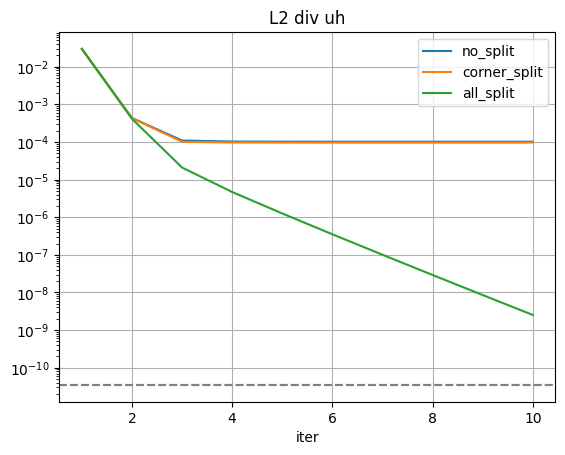

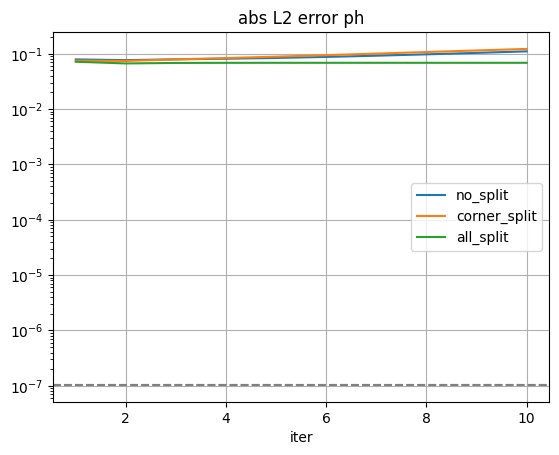

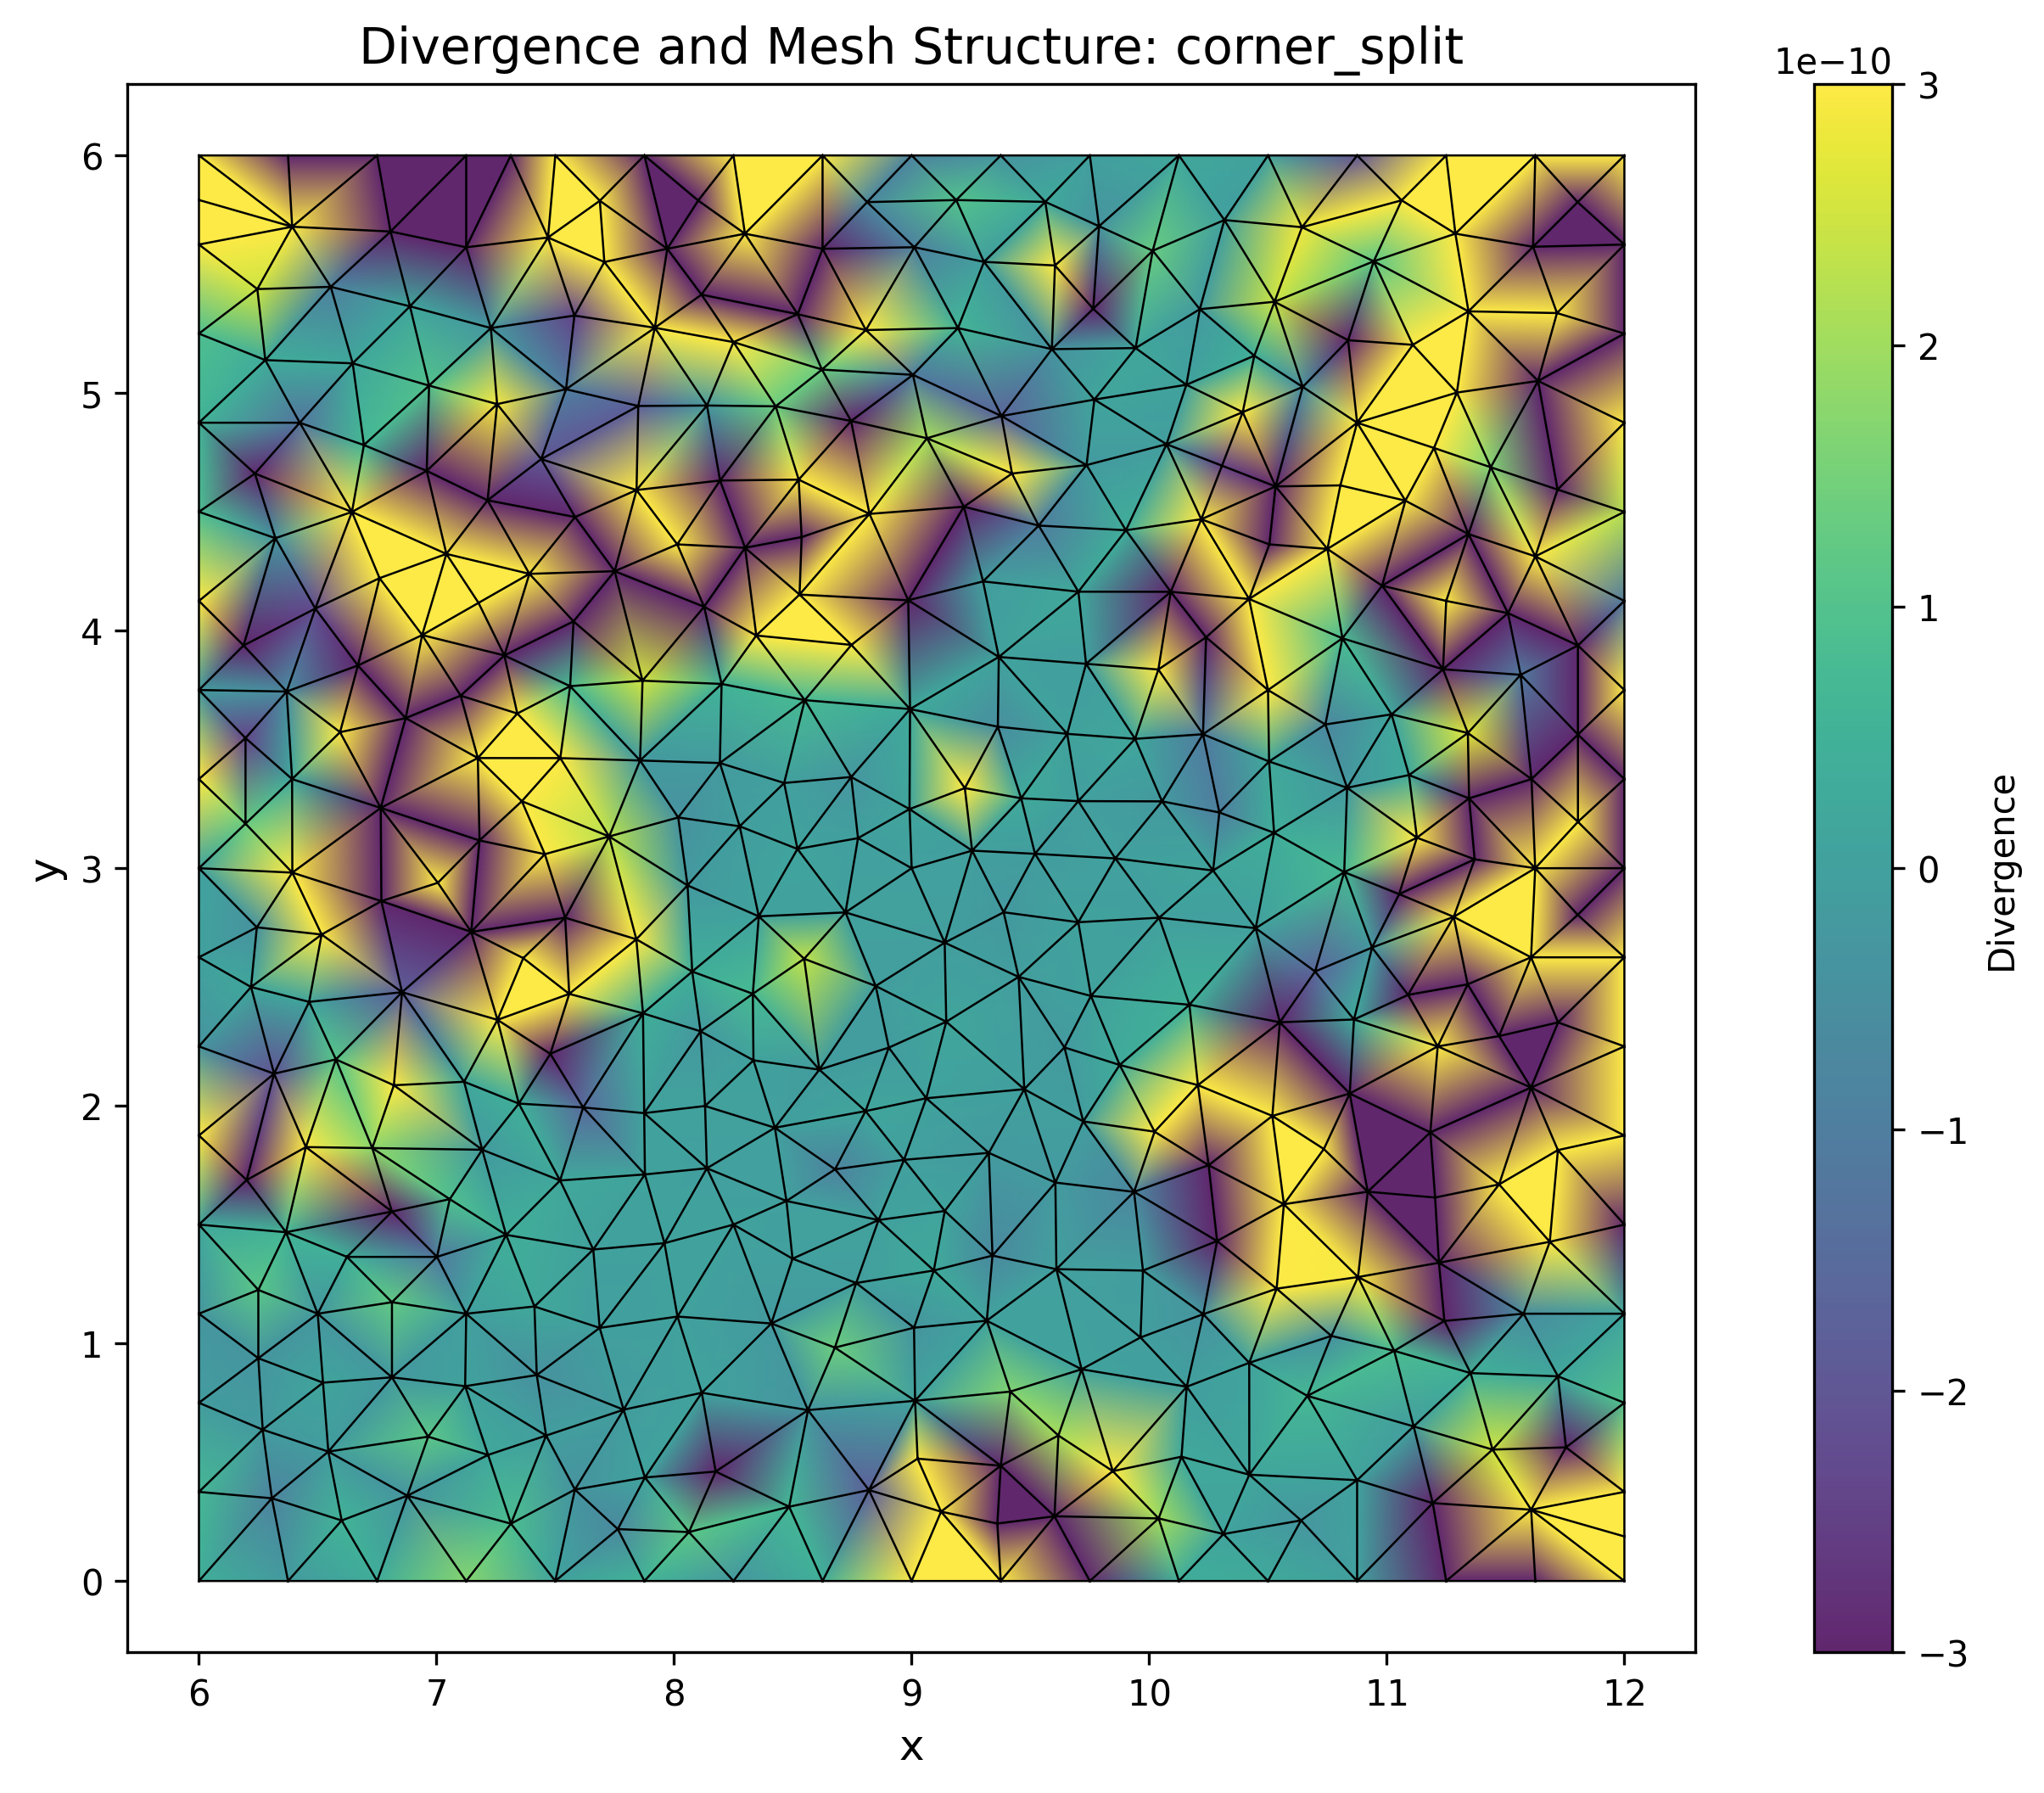

#####################################
####### START: IPM directly inhom default solver
####### opt_meshmod =  all_split
####### parameters: pdeg =  4 , nu =  1 , Ra =  1
####### rho =  100.0 , tol =  1e-11 , max_iter =  11
#####################################
####### M=  16
Old mesh had 803 triangles.
New mesh has 885 triangles.
    iter  L2 error uh  H1 error uh  L2 div uh  abs L2 error ph
0      1     6.99e-03         0.04   2.96e-02             0.07
1      2     7.68e-04         0.02   4.11e-04             0.07
2      3     7.67e-04         0.02   2.09e-05             0.07
3      4     7.68e-04         0.02   4.68e-06             0.07
4      5     7.68e-04         0.02   1.26e-06             0.07
5      6     7.68e-04         0.02   3.52e-07             0.07
6      7     7.68e-04         0.02   1.01e-07             0.07
7      8     7.68e-04         0.02   2.92e-08             0.07
8      9     7.68e-04         0.02   8.55e-09             0.07
9     10     7.68e-04         0.02   2

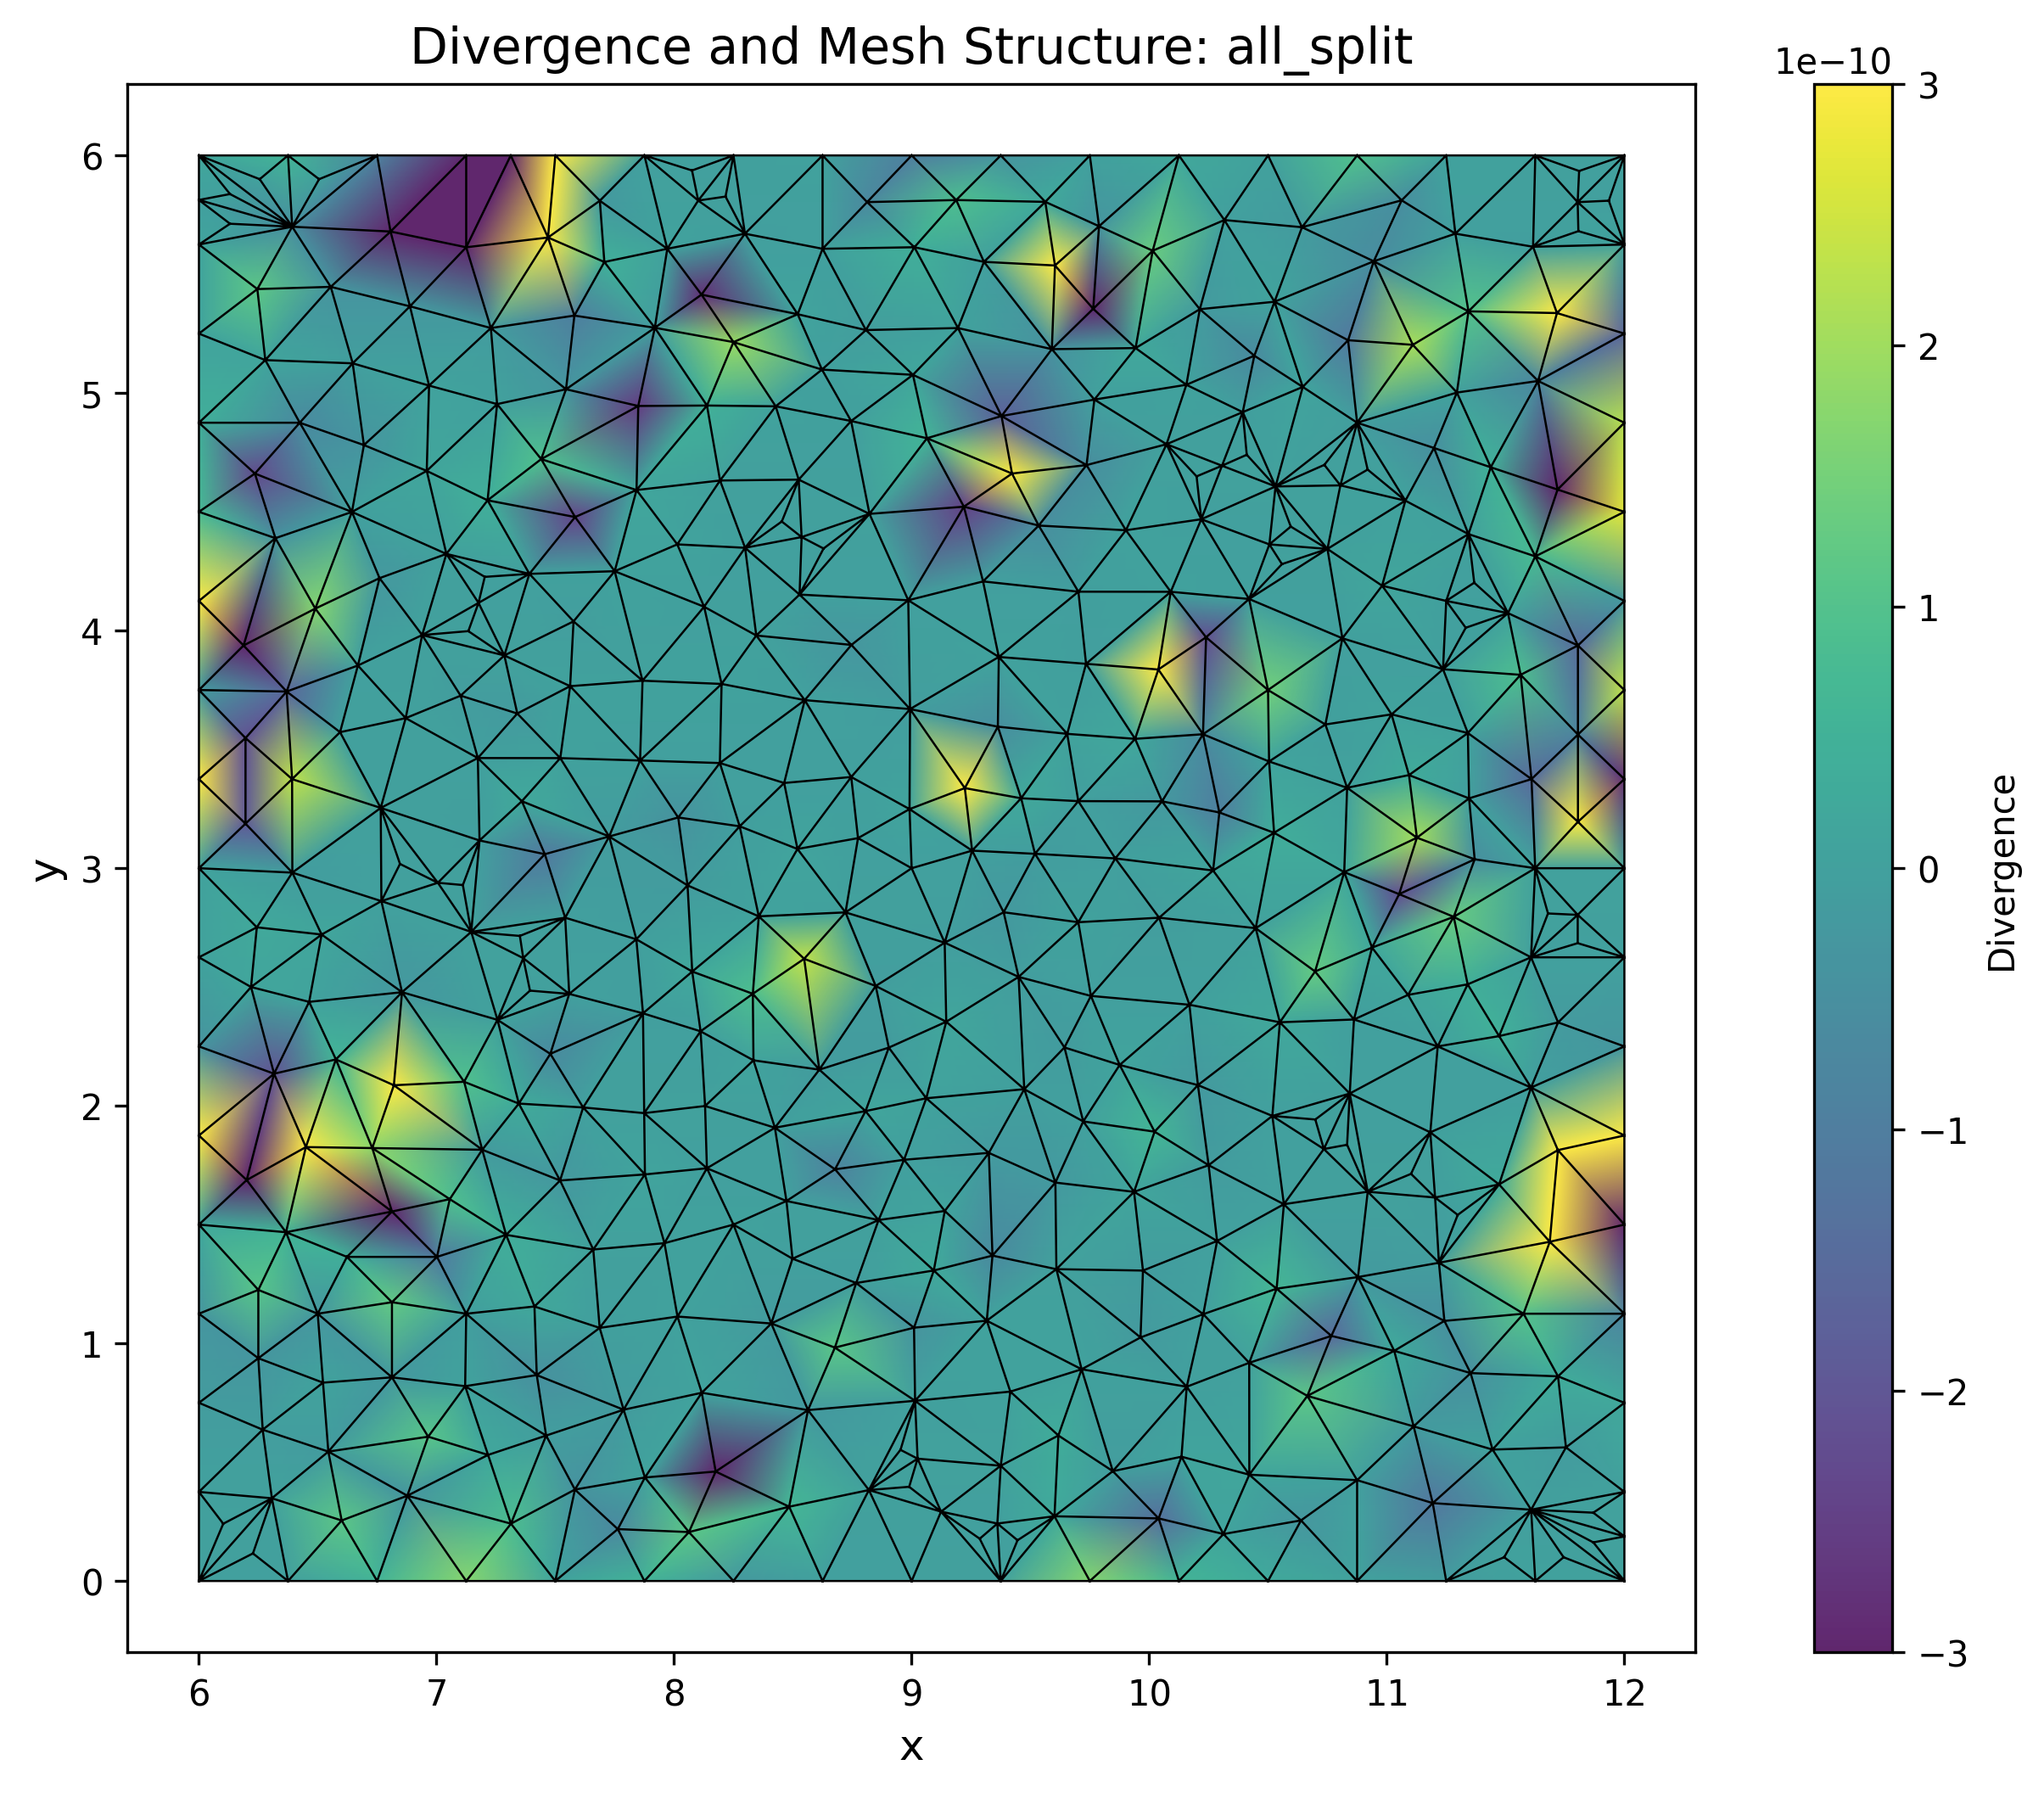

#####################################
####### START: IPM default solver
####### parameters: pdeg =  4 , nu =  1 , Ra =  1
####### rho =  100.0 , tol =  1e-11 , max_iter =  10
#####################################
####### M=  4
Old mesh had 52 triangles.
New mesh has 68 triangles.
####### M=  8
Old mesh had 203 triangles.
New mesh has 233 triangles.
####### M=  16
Old mesh had 803 triangles.
New mesh has 885 triangles.
####### M=  32
Old mesh had 3160 triangles.
New mesh has 3360 triangles.
####### M=  64
Old mesh had 12695 triangles.
New mesh has 13599 triangles.
Errortable for rho = 100.0 :
   meshsize     h    Time  iter  L2 error uh  H1 error uh  L2 div uh  \
0         4  1.77    3.80    10     4.65e-01     3.55e+00   2.20e-08   
1         8  0.95   19.12    10     2.14e-02     3.38e-01   1.32e-08   
2        16  0.49   32.70    10     7.68e-04     2.50e-02   2.53e-09   
3        32  0.24  128.88    10     2.35e-05     1.56e-03   9.99e-11   
4        64  0.12  514.98    10     7.15e

In [13]:
######## parameters defined by user ########
pdeg=4
nu = 1
Ra = 1
rho = Constant(1e2)
tol_div = 1e-11     # for IPM

domain =  Rectangle(dolfin.Point(6.0,0.0),dolfin.Point(12.0,6.0))

meshsize = 16

######### Choose method & solver #########
opt_method_solver = ["IPM", "directly inhom", "default solver"]

method = opt_method_solver[0].split()[0]
methodtype = opt_method_solver[0].split()[-1]
bc_imposition = opt_method_solver[1]
lin_solver = opt_method_solver[2]

######### Choose form of bilinearform rhs #########
opt_gradform = 0

######### Choose pressure example options #########
opt_velocity_ex = "manufactured"

######### Choose pressure example options #########
opt_pressure_ex = "sinoidal"

######### Choose perturbation of boundary extension ########
opt_bd_pert = "analytically divfree pert"

######### Choose to correct the boundary interpolation gh via bubble function
opt_gh_cor = 1

########################################################################################################################################################################
#################### Figure 4: div u plot over mesh and Figure 5: IPM errors over number of iterations (no mod., corner mod. and full mod.)
########################################################################################################################################################################

######### choose mesh modification #########
counter = 0
for opt_divuh_meshplot in [0,1]: # option to plot divergence over mesh
    if opt_divuh_meshplot == 1:
        max_iter = 11
        meshmod_options = ["corner_split","all_split"]
    else:
        max_iter = 10
        meshmod_options = ["no_split","corner_split","all_split"]

    for opt_meshmod in meshmod_options:

        #%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%
        print("#####################################")
        print("####### START:",methodtype, bc_imposition, lin_solver)
        print("####### opt_meshmod = ", opt_meshmod)
        print("####### parameters: pdeg = ", pdeg, ", nu = ", nu, ", Ra = ", Ra)
        print("####### rho = ", float(rho), ", tol = ", tol_div, ", max_iter = ", max_iter)
        print("#####################################")

        ######### Initialise DataFrame for error data of methods solution ##########
        errortable = pd.DataFrame()

        print("####### M= ", meshsize)
        mesh = generate_mesh(domain, meshsize)
        if opt_meshmod == "all_split":
            mesh = mesh_allsplit(mesh, 0)
        elif opt_meshmod == "corner_split":         # no interior split (but corners fixed)
            mesh = mesh_cornermod(mesh, 0)
        elif opt_meshmod == "no_split":
            mesh = mesh

        # velocity finite element space
        V = VectorFunctionSpace(mesh, "Lagrange", pdeg)

        # pressure finite element space
        DG = FunctionSpace(mesh, "DG", pdeg-1)
        hmax = mesh.hmax()
        x = SpatialCoordinate(mesh)
        n = FacetNormal(mesh)


        # Exact Velocity (u_e) - Stays the same
        ue = Expression((
            "sin(pi*x[0]) * cos(pi*x[1])",
            "-cos(pi*x[0]) * sin(pi*x[1])"
        ), degree=pdeg+2)

        # Exact Pressure (p) - A standard cosine bell scaled by Ra
        p = Expression("Ra * cos(pi*x[0]) * cos(pi*x[1])", Ra=Ra, degree=pdeg)

        # The Corrected Forcing Function (f)
        # f_x = 2*pi^2*sin(pi*x[0])*cos(pi*x[1]) - Ra*pi*sin(pi*x[0])*cos(pi*x[1])
        # f_y = -2*pi^2*cos(pi*x[0])*sin(pi*x[1]) - Ra*pi*cos(pi*x[0])*sin(pi*x[1])

        f = Expression((
            "(2*pow(pi, 2) - Ra*pi) * sin(pi*x[0]) * cos(pi*x[1])",
            "(-2*pow(pi, 2) - Ra*pi) * cos(pi*x[0]) * sin(pi*x[1])"
        ), Ra=Ra, degree=pdeg)
        # # exact velocity solution
        # ue = Expression(("-x[1]*(1.0-(1.0/(x[0]*x[0]+x[1]*x[1])))", \
        #         "x[0]*(1.0-(1.0/(x[0]*x[0]+x[1]*x[1])))"),degree=pdeg+2)

        # # exact pressure solution and right hand side
        # c = 10.0
        # p = Expression("cst * sin(0.025 * pi * (x[0]-12))*sin(0.05 * pi * x[1] )",cst = c*Ra,degree=pdeg)
        # f = Expression(("cst* 0.025 * pi * cos(0.025 * pi * (x[0]-12)) * sin(0.05 * pi * x[1])","cst* 0.05 * pi * cos(0.05 * pi * x[1]) * sin(0.025 * pi * (x[0]-12))"), cst = c*Ra, degree=pdeg)
        # # make pressure mean free
        pe = pressure_zero_mean(p, mesh, pdeg, 'exact')

        # boundary extension
        u_boundary = ue

        # boundary correction
        gh1 = Function(V)
        gh1 = interpolate(u_boundary,V)
        gh = Function(V)
        gh = boundary_modification(V, mesh, gh1)


        ########## SOLVE ##################
        t0 = time.time()  # <--- Start timer
        (uh, div_uh_norm, ph, errortable_iter) = IPM(V, mesh, f, gh, pdeg, nu, rho, max_iter, tol_div, ue, pe)
        t1 = time.time()  # <--- Stop timer
        cpu_time = t1 - t0 # <--- Calculate duration
        print(errortable_iter)
        errortable_iter.to_csv(f"errors_with_new_eqn_{opt_meshmod}_4.csv", index=False)

        # plot of div over mesh for corner mod. and full mod.
        # if opt_divuh_meshplot == 1:
        #     divuh = project(div(uh),DG)
        #     max_divuh = np.max(np.abs(divuh.vector()))
        #     print("max div u = ", max_divuh)
        #     plt.figure()
        #     plt.xlabel("x")
        #     plt.ylabel("y")
        #     c = plot(divuh, mode='color',vmin=-3e-10, vmax=3e-10)
        #     plt.colorbar(c)
        #     plot(mesh)

# plot of div over mesh for corner mod. and full mod.
        if opt_divuh_meshplot == 1:
            divuh = project(div(uh), DG)
            max_divuh = np.max(np.abs(divuh.vector()))
            print("max div u = ", max_divuh)

            # 1. Create a large, high-resolution canvas
            plt.figure(figsize=(12, 8), dpi=300)

            plt.title(f"Divergence and Mesh Structure: {opt_meshmod}", fontsize=14)
            plt.xlabel("x", fontsize=12)
            plt.ylabel("y", fontsize=12)

            # 2. Plot the colored divergence field
            # Using alpha=0.85 makes the color slightly transparent so the black mesh pops more
            c = plot(divuh, mode='color', vmin=-3e-10, vmax=3e-10, alpha=0.85)
            plt.colorbar(c, label="Divergence")

            # 3. Plot the Mesh with explicit, strong styling
            # 'k' sets the line color to pure black.
            # Increase linewidth if it's still too thin (e.g., 0.8 or 1.0)
            plot(mesh, color='k', linewidth=0.6)

            # 4. Save the plot in High-Quality formats before showing

            # Format A: High-Res PNG (Great for quick viewing)
            png_name = f"MeshPlot_{opt_meshmod}.png"
            plt.savefig(png_name, dpi=800, bbox_inches='tight')

            # Format B: Vector Graphic PDF (Best for infinite zooming and papers)
            pdf_name = f"MeshPlot_{opt_meshmod}.pdf"
            plt.savefig(pdf_name, format='pdf', bbox_inches='tight')

            print(f"Saved high-quality plots: {png_name} and {pdf_name}")

            # Display in the notebook
            plt.show()









        if opt_divuh_meshplot == 0:
            if counter == 0:
                ax_it_div = errortable_iter.plot(x='iter', y='L2 div uh', label=f"{opt_meshmod}", kind='line', logy = True, grid = True, title='L2 div uh')
                ax_it_L2p = errortable_iter.plot(x='iter', y='abs L2 error ph', label=f"{opt_meshmod}", kind='line', logy = True, grid = True, title='abs L2 error ph')
            else:
                errortable_iter.plot(x='iter', y='L2 div uh', label=f"{opt_meshmod}", ax = ax_it_div, kind='line', logy = True, grid = True, title='L2 div uh')
                errortable_iter.plot(x='iter', y='abs L2 error ph', label=f"{opt_meshmod}", ax = ax_it_L2p,  kind='line', logy = True, grid = True, title='abs L2 error ph')

                ax_it_div.axhline(y=3.5e-11, color = 'gray',  linestyle='--', label='SV limit')
                ax_it_L2p.axhline(y=1.04e-07, color = 'gray',  linestyle='--', label='SV limit')


            newrow_errors = errortable_iter.tail(1)
            newrow_errors.insert(0, 'meshsize', [meshsize])
            newrow_errors.insert(1, 'h', [hmax])
            newrow_errors.insert(2, 'Time', [cpu_time])  # <--- Add this line
            errortable = pd.concat([errortable, newrow_errors], ignore_index = True)

            print(errortable)

            counter = counter + 1


##########################################################################################################################
#################### Table 3 and 4: IPM errors over meshsize for rho = 10^2, 10^4
##########################################################################################################################
opt_meshmod = "all_split"
meshsizes = [4,8,16,32,64]
max_iter = 10
print("#####################################")
print("####### START:",methodtype, lin_solver)
print("####### parameters: pdeg = ", pdeg, ", nu = ", nu, ", Ra = ", Ra)

for rho in [Constant(1e2), Constant(1e4)]:
    print("####### rho = ", float(rho), ", tol = ", tol_div, ", max_iter = ", max_iter)
    print("#####################################")
    ######### Initialise DataFrame for error data of methods solution ##########
    errortable = pd.DataFrame()

    for meshsize in meshsizes:
        print("####### M= ", meshsize)
        mesh = generate_mesh(domain, meshsize)
        mesh = mesh_allsplit(mesh, 0)

        # velocity finite element space
        V = VectorFunctionSpace(mesh, "Lagrange", pdeg)

        # pressure finite element space
        DG = FunctionSpace(mesh, "DG", pdeg-1)
        hmax = mesh.hmax()
        x = SpatialCoordinate(mesh)
        n = FacetNormal(mesh)

        # # exact velocity solution
        # ue = Expression(("-x[1]*(1.0-(1.0/(x[0]*x[0]+x[1]*x[1])))", \
        #             "x[0]*(1.0-(1.0/(x[0]*x[0]+x[1]*x[1])))"),degree=pdeg+2)

        # # exact pressure solution and right hand side
        # c = 10.0
        # p = Expression("cst * sin(0.025 * pi * (x[0]-12))*sin(0.05 * pi * x[1] )",cst = c*Ra,degree=pdeg)
        # f = Expression(("cst* 0.025 * pi * cos(0.025 * pi * (x[0]-12)) * sin(0.05 * pi * x[1])","cst* 0.05 * pi * cos(0.05 * pi * x[1]) * sin(0.025 * pi * (x[0]-12))"), cst = c*Ra, degree=pdeg)
        # # make pressure mean free
# Exact Velocity (u_e) - Stays the same
        ue = Expression((
            "sin(pi*x[0]) * cos(pi*x[1])",
            "-cos(pi*x[0]) * sin(pi*x[1])"
        ), degree=pdeg+2)

        # Exact Pressure (p) - A standard cosine bell scaled by Ra
        p = Expression("Ra * cos(pi*x[0]) * cos(pi*x[1])", Ra=Ra, degree=pdeg)

        # The Corrected Forcing Function (f)
        # f_x = 2*pi^2*sin(pi*x[0])*cos(pi*x[1]) - Ra*pi*sin(pi*x[0])*cos(pi*x[1])
        # f_y = -2*pi^2*cos(pi*x[0])*sin(pi*x[1]) - Ra*pi*cos(pi*x[0])*sin(pi*x[1])

        f = Expression((
            "(2*pow(pi, 2) - Ra*pi) * sin(pi*x[0]) * cos(pi*x[1])",
            "(-2*pow(pi, 2) - Ra*pi) * cos(pi*x[0]) * sin(pi*x[1])"
        ), Ra=Ra, degree=pdeg)

        pe = pressure_zero_mean(p, mesh, pdeg, 'exact')

        # boundary extension
        u_boundary = ue

        # boundary correction
        gh1 = Function(V)
        gh1 = interpolate(u_boundary,V)
        gh = Function(V)
        gh = boundary_modification(V, mesh, gh1)

        ########## SOLVE ##################
        # (uh, div_uh_norm, ph, errortable_iter) = IPM(V, mesh, f, gh, pdeg, nu, rho, max_iter, tol_div, opt_method_solver, ue, pe)
        ########## SOLVE ##################
        t0 = time.time()  # <--- Start timer
        (uh, div_uh_norm, ph, errortable_iter) = IPM(V, mesh, f, gh, pdeg, nu, rho, max_iter, tol_div, ue, pe)
        t1 = time.time()  # <--- Stop timer
        cpu_time = t1 - t0 # <--- Calculate duration

        newrow_errors = errortable_iter.tail(1)             # last row of Iterations is end IPM result
        newrow_errors.insert(0, 'meshsize', [meshsize])
        newrow_errors.insert(1, 'h', [hmax])
        newrow_errors.insert(2, 'Time', [cpu_time])  # <--- Add this line
        errortable = pd.concat([errortable, newrow_errors], ignore_index = True)

    print(f"Errortable for rho = {float(rho)} :")
    print(errortable)
    errortable.to_csv(f"errors__with_new_eqn_rho_{float(rho)}_4.csv", index=False)


plt.show()


## The below code file is from main_IPM_pressure-robustness.py file

#####################################
####### START: IPM default solver
####### parameters: pdeg =  4 , nu =  1 , Ra =  1.0
####### rho =  100.0 , tol =  1e-11 , max_iter =  1
#####################################
####### M=  4
Old mesh had 52 triangles.
New mesh has 68 triangles.
   iter  L2 error uh  H1 error uh  L2 div uh  abs L2 error ph
0     1         0.45         3.43       0.07             6.44
####### M=  8
Old mesh had 203 triangles.
New mesh has 233 triangles.
   iter  L2 error uh  H1 error uh  L2 div uh  abs L2 error ph
0     1         0.02         0.32       0.03             0.79
####### M=  16
Old mesh had 803 triangles.
New mesh has 885 triangles.
   iter  L2 error uh  H1 error uh  L2 div uh  abs L2 error ph
0     1     6.99e-03         0.04       0.03             0.07
####### M=  32
Old mesh had 3160 triangles.
New mesh has 3360 triangles.
   iter  L2 error uh  H1 error uh  L2 div uh  abs L2 error ph
0     1     6.95e-03         0.03       0.03             0.04
####### 

KeyboardInterrupt: 

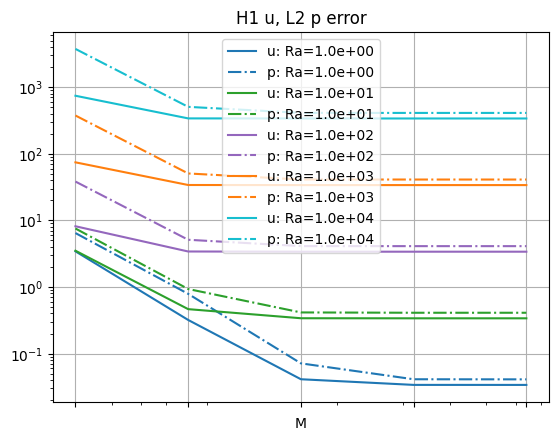

In [14]:
colors = {
    "steelblue": (31/255, 119/255, 180/255),
    "forestgreen": (44/255, 160/255, 44/255),
    "mediumpurple": (148/255, 103/255, 189/255),
    "darkorange": (255/255, 127/255, 14/255),
    "darkturquoise": (23/255, 190/255, 207/255),
}
Ra_colors = list(colors.values())

######## parameters defined by user ########
pdeg=4
nu = 1
Ras = [1e0,1e1, 1e2, 1e3, 1e4]
rho = Constant(1e2)
tol_div = 1e-11

domain =  Rectangle(dolfin.Point(6.0,0.0),dolfin.Point(12.0,6.0))

meshsizes = [4, 8, 16, 32, 64]

######### Choose method & solver #########
opt_method_solver = ["IPM", "directly inhom", "default solver"]

method = opt_method_solver[0].split()[0]
methodtype = opt_method_solver[0].split()[-1]
lin_solver = opt_method_solver[2]

for max_iter in  [1, 5, 10]:
    counter = 0

    for Ra in Ras:
        #%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%
        print("#####################################")
        print("####### START:",methodtype, lin_solver)
        print("####### parameters: pdeg = ", pdeg, ", nu = ", nu, ", Ra = ", Ra)
        print("####### rho = ", float(rho), ", tol = ", tol_div, ", max_iter = ", max_iter)
        print("#####################################")

        ######### Initialise DataFrame for error data of methods solution ##########
        errortable = pd.DataFrame()

        for meshsize in meshsizes:
            print("####### M= ", meshsize)
            mesh = generate_mesh(domain, meshsize)
            mesh = mesh_allsplit(mesh, 0)

            # velocity finite element space
            V = VectorFunctionSpace(mesh, "Lagrange", pdeg)

            # pressure finite element space
            DG = FunctionSpace(mesh, "DG", pdeg-1)
            hmax = mesh.hmax()
            x = SpatialCoordinate(mesh)
            n = FacetNormal(mesh)
            # Exact Velocity (u_e) - Stays the same
            ue = Expression((
                "sin(pi*x[0]) * cos(pi*x[1])",
                "-cos(pi*x[0]) * sin(pi*x[1])"
            ), degree=pdeg+2)

            # Exact Pressure (p) - A standard cosine bell scaled by Ra
            p = Expression("Ra * cos(pi*x[0]) * cos(pi*x[1])", Ra=Ra, degree=pdeg)

            # The Corrected Forcing Function (f)
            # f_x = 2*pi^2*sin(pi*x[0])*cos(pi*x[1]) - Ra*pi*sin(pi*x[0])*cos(pi*x[1])
            # f_y = -2*pi^2*cos(pi*x[0])*sin(pi*x[1]) - Ra*pi*cos(pi*x[0])*sin(pi*x[1])

            f = Expression((
                "(2*pow(pi, 2) - Ra*pi) * sin(pi*x[0]) * cos(pi*x[1])",
                "(-2*pow(pi, 2) - Ra*pi) * cos(pi*x[0]) * sin(pi*x[1])"
            ), Ra=Ra, degree=pdeg)
            # # exact velocity solution
            # ue = Expression(("-x[1]*(1.0-(1.0/(x[0]*x[0]+x[1]*x[1])))", \
            #             "x[0]*(1.0-(1.0/(x[0]*x[0]+x[1]*x[1])))"),degree=pdeg+2)

            # # exact pressure solution and right hand side (sinoidal), case opt_gradform == 0
            # c = 10.0
            # p = Expression("cst * sin(0.025 * pi * (x[0]-12))*sin(0.05 * pi * x[1] )",cst = c*Ra,degree=pdeg)
            # f = Expression(("cst* 0.025 * pi * cos(0.025 * pi * (x[0]-12)) * sin(0.05 * pi * x[1])","cst* 0.05 * pi * cos(0.05 * pi * x[1]) * sin(0.025 * pi * (x[0]-12))"), cst = c*Ra, degree=pdeg)
            # # make pressure mean free
            pe = pressure_zero_mean(p, mesh, pdeg, 'exact')

            # boundary extension
            u_boundary = ue

            # boundary correction
            gh1 = Function(V)
            gh1 = interpolate(u_boundary,V)
            gh = Function(V)
            gh = boundary_modification(V, mesh, gh1)


        ########## SOLVE ##################
            (uh, div_uh_norm, ph, errortable_iter) = IPM(V, mesh, f, gh, pdeg, nu, rho, max_iter, tol_div, ue, pe)
            print(errortable_iter)

            newrow_errors = errortable_iter.tail(1)             # last row of Iterations is end IPM result
            newrow_errors.insert(0, 'meshsize', [meshsize])
            newrow_errors.insert(1, 'h', [hmax])
            errortable = pd.concat([errortable, newrow_errors], ignore_index = True)

        print(errortable)

        if counter == 0:
            axis = errortable.plot(x='meshsize', y=['H1 error uh', 'abs L2 error ph'], label=["u: Ra=%.1e"%Ra, "p: Ra=%.1e"%Ra], color = Ra_colors[counter], kind='line', style = ['-','-.'], logy = True, logx = True, grid = True, title="H1 u, L2 p error", xticks=meshsizes, xlabel = 'M')
            axis.set_xticks(meshsizes)
            axis.set_xscale("log", base=2)
        else:
            errortable.plot(x='meshsize', y=['H1 error uh', 'abs L2 error ph'], label=["u: Ra=%.1e"%Ra, "p: Ra=%.1e"%Ra], color = Ra_colors[counter], kind='line', style = ['-','-.'],  logy = True,  logx = True, grid = True, ax = axis, title="H1 u, L2 p error", xticks=meshsizes, xlabel = 'M')


        counter = counter + 1

plt.show() # plot of errors for different Ra over meshsize

## The below code is from the file main_SV_TH_pressure-robustness.py file

In [ ]:
colors = {
    "forestgreen": (44/255, 160/255, 44/255),
    "mediumpurple": (148/255, 103/255, 189/255),
    "darkorange": (255/255, 127/255, 14/255),
    "darkturquoise": (23/255, 190/255, 207/255),
}
Ra_colors = list(colors.values())

domain =  Rectangle(dolfin.Point(6.0,0.0),dolfin.Point(12.0,6.0))

######## parameters defined by user ########
pdeg=4
nu = 1
Ras = [1e1, 1e2, 1e3, 1e4]

meshsizes = [4, 8, 16, 32, 64]

methods = [["mixed method SV", "inhom", "mumps"], ["mixed method TH", "inhom", "mumps"]]

for opt_method_solver in methods:
    counter = 0

    method = opt_method_solver[0].split()[0]
    methodtype = opt_method_solver[0].split()[-1]
    lin_solver = opt_method_solver[2]

    for Ra in Ras:
        #%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%
        print("#####################################")
        print("####### START:",methodtype, lin_solver)
        print("####### parameters: pdeg = ", pdeg, ", nu = ", nu, ", Ra = ", Ra)
        print("#####################################")

        ######### Initialise DataFrame for error data of methods solution ##########
        errortable = pd.DataFrame()

        for meshsize in meshsizes:
            print("####### M= ", meshsize)

            mesh = generate_mesh(domain, meshsize)
            mesh = mesh_allsplit(mesh, 0)

            # velocity finite element space
            V = VectorFunctionSpace(mesh, "Lagrange", pdeg)

            # pressure finite element space
            DG = FunctionSpace(mesh, "DG", pdeg-1)
            hmax = mesh.hmax()
            x = SpatialCoordinate(mesh)
            n = FacetNormal(mesh)
            # Exact Velocity (u_e) - Stays the same
            ue = Expression((
                "sin(pi*x[0]) * cos(pi*x[1])",
                "-cos(pi*x[0]) * sin(pi*x[1])"
            ), degree=pdeg+2)

            # Exact Pressure (p) - A standard cosine bell scaled by Ra
            p = Expression("Ra * cos(pi*x[0]) * cos(pi*x[1])", Ra=Ra, degree=pdeg)

            # The Corrected Forcing Function (f)
            # f_x = 2*pi^2*sin(pi*x[0])*cos(pi*x[1]) - Ra*pi*sin(pi*x[0])*cos(pi*x[1])
            # f_y = -2*pi^2*cos(pi*x[0])*sin(pi*x[1]) - Ra*pi*cos(pi*x[0])*sin(pi*x[1])

            f = Expression((
                "(2*pow(pi, 2) - Ra*pi) * sin(pi*x[0]) * cos(pi*x[1])",
                "(-2*pow(pi, 2) - Ra*pi) * cos(pi*x[0]) * sin(pi*x[1])"
            ), Ra=Ra, degree=pdeg)
            # # exact velocity solution
            # ue = Expression(("-x[1]*(1.0-(1.0/(x[0]*x[0]+x[1]*x[1])))", \
            #         "x[0]*(1.0-(1.0/(x[0]*x[0]+x[1]*x[1])))"),degree=pdeg+2)

            # # exact pressure solution and right hand side
            # c = 10.0
            # p = Expression("cst * sin(0.025 * pi * (x[0]-12))*sin(0.05 * pi * x[1] )",cst = c*Ra,degree=pdeg)
            # f = Expression(("cst* 0.025 * pi * cos(0.025 * pi * (x[0]-12)) * sin(0.05 * pi * x[1])","cst* 0.05 * pi * cos(0.05 * pi * x[1]) * sin(0.025 * pi * (x[0]-12))"), cst = c*Ra, degree=pdeg)
            # # make pressure mean free
            pe = pressure_zero_mean(p, mesh, pdeg, 'exact')

            # boundary extension
            u_boundary = ue

            # boundary correction
            gh1 = Function(V)
            gh1 = interpolate(u_boundary,V)
            gh = Function(V)
            gh = boundary_modification(V, mesh, gh1)


            ########## SOLVE ##################
            (uh, div_uh_norm, ph) = mixed_method(methodtype, mesh, f, gh, pdeg, nu, opt_method_solver)

            # Calculating the errors
            L2_u = errornorm(ue, uh, norm_type='L2', degree_rise=3)
            H1_u = errornorm(ue, uh, norm_type='H1', degree_rise=3)
            L2_p_abs, L2_p_rel = pressure_error(pe, ph, mesh)
            newrow_errors = pd.DataFrame({'meshsize': [meshsize], 'h': [hmax], 'L2 error uh': [L2_u], 'H1 error uh': [H1_u], 'L2 div uh': [div_uh_norm],
                                            'abs L2 error ph': [L2_p_abs]})
            errortable = pd.concat([errortable, newrow_errors], ignore_index = True)


        print(errortable)

        # plot final errors (for one Ra) over meshsize
        if counter == 0:
            axis = errortable.plot(x='meshsize', y=['H1 error uh', 'abs L2 error ph'], label=["u: Ra=%.1e"%Ra, "p: Ra=%.1e"%Ra], color = Ra_colors[counter], kind='line', style = ['-','-.'], logy = True, logx = True, grid = True, title="H1 u, L2 p error", xticks=meshsizes, xlabel = 'M')
            axis.set_xticks(meshsizes)
            axis.set_xscale("log", base=2)
        else:
            errortable.plot(x='meshsize', y=['H1 error uh', 'abs L2 error ph'], label=["u: Ra=%.1e"%Ra, "p: Ra=%.1e"%Ra], color = Ra_colors[counter], kind='line', style = ['-','-.'],  logy = True,  logx = True, grid = True, ax = axis, title="H1 u, L2 p error", xticks=meshsizes, xlabel = 'M')


        counter = counter + 1

    plt.show()

## The below code file is from main_SV_errortable-bd-correction.py file

In [ ]:
colors = {
    "steelblue": (31/255, 119/255, 180/255),
    "forestgreen": (44/255, 160/255, 44/255),
    "mediumpurple": (148/255, 103/255, 189/255),
    "darkorange": (255/255, 127/255, 14/255),
    "darkturquoise": (23/255, 190/255, 207/255),
}
Ra_colors = list(colors.values())

domain =  Rectangle(dolfin.Point(6.0,0.0),dolfin.Point(12.0,6.0))

######## parameters defined by user ########
pdeg=4
nu = 1
Ra = 1
meshsizes = [4, 8, 16, 32, 64]

######### Choose method & solver #########
opt_method_solver = ["mixed method SV", "inhom", "mumps"]

method = opt_method_solver[0].split()[0]
methodtype = opt_method_solver[0].split()[-1]
lin_solver = opt_method_solver[2]


#%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%-%

for opt_gh_cor in [1, 0]: # loop over parameter for correcting the boundary interpolation gh via bubble function 1 or not 0
    errortable = pd.DataFrame()
    print("#####################################")
    print("####### START:",methodtype, lin_solver)
    print("####### boundary correction: ", opt_gh_cor)
    print("####### parameters: pdeg = ", pdeg, ", nu = ", nu, ", Ra = ", Ra)
    print("#####################################")
    for meshsize in meshsizes:
        mesh = generate_mesh(domain, meshsize)
        mesh = mesh_allsplit(mesh, 0)

        # velocity finite element space
        V = VectorFunctionSpace(mesh, "Lagrange", pdeg)

        # pressure finite element space
        DG = FunctionSpace(mesh, "DG", pdeg-1)
        hmax = mesh.hmax()
        x = SpatialCoordinate(mesh)
        n = FacetNormal(mesh)

        # Exact Velocity (u_e) - Stays the same
        ue = Expression((
            "sin(pi*x[0]) * cos(pi*x[1])",
            "-cos(pi*x[0]) * sin(pi*x[1])"
        ), degree=pdeg+2)

        # Exact Pressure (p) - A standard cosine bell scaled by Ra
        p = Expression("Ra * cos(pi*x[0]) * cos(pi*x[1])", Ra=Ra, degree=pdeg)

        # The Corrected Forcing Function (f)
        # f_x = 2*pi^2*sin(pi*x[0])*cos(pi*x[1]) - Ra*pi*sin(pi*x[0])*cos(pi*x[1])
        # f_y = -2*pi^2*cos(pi*x[0])*sin(pi*x[1]) - Ra*pi*cos(pi*x[0])*sin(pi*x[1])

        f = Expression((
            "(2*pow(pi, 2) - Ra*pi) * sin(pi*x[0]) * cos(pi*x[1])",
            "(-2*pow(pi, 2) - Ra*pi) * cos(pi*x[0]) * sin(pi*x[1])"
        ), Ra=Ra, degree=pdeg)
        # # exact velocity solution
        # ue = Expression(("-x[1]*(1.0-(1.0/(x[0]*x[0]+x[1]*x[1])))", \
        #             "x[0]*(1.0-(1.0/(x[0]*x[0]+x[1]*x[1])))"),degree=pdeg+2)

        # # exact pressure solution and right hand side
        # c = 10.0
        # p = Expression("cst * sin(0.025 * pi * (x[0]-12))*sin(0.05 * pi * x[1] )",cst = c*Ra,degree=pdeg)
        # f = Expression(("cst* 0.025 * pi * cos(0.025 * pi * (x[0]-12)) * sin(0.05 * pi * x[1])","cst* 0.05 * pi * cos(0.05 * pi * x[1]) * sin(0.025 * pi * (x[0]-12))"), cst = c*Ra, degree=pdeg)
        # # make pressure mean free
        pe = pressure_zero_mean(p, mesh, pdeg, 'exact')


        u_boundary = ue

        # boundary correction
        if opt_gh_cor == 0:
            gh = Function(V)
            gh = interpolate(u_boundary,V)
        elif opt_gh_cor == 1:
            gh1 = Function(V)
            gh1 = interpolate(u_boundary,V)
            gh = Function(V)
            gh = boundary_modification(V, mesh, gh1)


        ########## SOLVE ##################

        (uh, div_uh_norm, ph) = mixed_method(methodtype, mesh, f, gh, pdeg, nu, opt_method_solver)

        # Calculating the errors
        L2_u = errornorm(ue, uh, norm_type='L2', degree_rise=3)
        H1_u = errornorm(ue, uh, norm_type='H1', degree_rise=3)
        L2_p_abs, L2_p_rel = pressure_error(pe, ph, mesh)
        newrow_errors = pd.DataFrame({'meshsize': [meshsize], 'h': [hmax], 'L2 error uh': [L2_u], 'H1 error uh': [H1_u], 'L2 div uh': [div_uh_norm],
                                        'abs L2 error ph': [L2_p_abs]})
        errortable = pd.concat([errortable, newrow_errors], ignore_index = True)

    print(errortable)